# Train your own simple Language ID system with Naive Bayes and Character features

This notebook walks you through training and evaluating a simple **language identification (LID)** model locally.

We use two datasets in this notebook:
- CV LID: Common Voice LID, containing all of the text from Common Voice projects, covering over 300 languages. It has approximately 20 Million examples, but for our use case we will subsample this in order to train more quickly.
- CommonLID: The evaluation-only language ID dataset from Common Crawl, with over 300,000 examples from a total of more than 100 languages.



## Imports

We rely entirely on standard scientific Python libraries:

- **pandas** -- for reading TSV files in chunks
- **scikit-learn** -- for the vectorizer and classifier
- **numpy** -- for array operations during evaluation
- **tqdm** -- for a progress bar during the training loop
- **math** -- to estimate the total number of chunks upfront

Additionally, we will import some utility functions

In [1]:
import math

import numpy as np
import pandas as pd
import os
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from tqdm.notebook import tqdm
from fox_progress_bar import ProgressBar
from datacollective import download_dataset
# utility functions
from language_id.data import (load_commonlid, load_commonvoice_lid,
                              sample, take_fewshot_examples, COMMON_VOICE_LID_DATASET_ID, COMMON_LID_DATASET_ID)
from language_id.lang_codes_mapping import to_iso3

In [1]:
%env MDC_API_KEY=<YOUR API HERE>

env: MDC_API_KEY=<YOUR API HERE>


## Download, load, and sample the common voice LID dataset

In [3]:
sample_p = 0.15
SEED = 42

cv_lid_path = download_dataset(COMMON_VOICE_LID_DATASET_ID)
parent_dir = str(cv_lid_path).rsplit("/", 1)[0]
cv_lid_untarred_path = (parent_dir
                        + "/"
                        + "mozilla-common-voice-text-language-ident-b1b3aae0")

if not os.path.exists(cv_lid_untarred_path):
    os.system(f"mkdir {cv_lid_untarred_path}")
    os.system(f"tar -xzf {cv_lid_path} -C {cv_lid_untarred_path}")

path_to_file = cv_lid_untarred_path + "/mcv_text_lid/mcv_text_lid.tsv"


def get_split_file_path(split):
    return f"{cv_lid_untarred_path}/mcv_text_lid/" + f"{split}_sample.tsv"

for split in ("train", "test", "dev"):
    if os.path.exists(f"{get_split_file_path(split)}"):
        os.system(f"rm {get_split_file_path(split)}")

print("Processing 20 million row files from disk to create sampled train, dev, and test files.")
rows_processed = 0
pb = ProgressBar(total_size=19750000, unit="Rows")
for chunk in pd.read_csv(path_to_file, sep="\t", chunksize=100_000):
    for split, grp in chunk.groupby("split"):
        path_to_split_file = get_split_file_path(split)
        grp.sample(frac=sample_p, random_state=SEED).to_csv(
            path_to_split_file, sep="\t", mode="a", index=False,
            header=not os.path.exists(path_to_split_file)
        )
    pb.update(100_000)

cv_lid_train = pd.read_csv(get_split_file_path("train"), sep="\t")
cv_lid_dev = pd.read_csv(get_split_file_path("dev"), sep="\t")
cv_lid_test = pd.read_csv(get_split_file_path("test"), sep="\t")

cv_lid_train["lang"] = cv_lid_train["lang"].astype(str).map(to_iso3)
cv_lid_dev["lang"] = cv_lid_dev["lang"].astype(str).map(to_iso3)
cv_lid_test["lang"] = cv_lid_test["lang"].astype(str).map(to_iso3)

print("Finished.")


Processing 20 million row files from disk to create sampled train, dev, and test files.
█████████████████████████████████████████████████🦊 100.0% (19800000.0 Rows/19750000.0 Rows) 507748.8 Rows/s ETA: --:--Finished.


In [4]:
#
# If you have a lot of free RAM you can use this more straightforward way to load and sample :)
#
"""
sample_p = 0.15
total_cv_lid = load_commonvoice_lid()
cv_lid_train = total_cv_lid[total_cv_lid.split == "train"]
cv_lid_train = cv_lid_train.sample(int(len(cv_lid_train) * sample_p))

cv_lid_dev = total_cv_lid[total_cv_lid.split == "dev"]
cv_lid_dev = cv_lid_dev.sample(int(len(cv_lid_dev) * sample_p))

cv_lid_test = total_cv_lid[total_cv_lid.split == "test"]
cv_lid_test = cv_lid_test.sample(int(len(cv_lid_test) * sample_p))

total_cv_lid = None
"""

'\nsample_p = 0.15\ntotal_cv_lid = load_commonvoice_lid()\ncv_lid_train = total_cv_lid[total_cv_lid.split == "train"]\ncv_lid_train = cv_lid_train.sample(int(len(cv_lid_train) * sample_p))\n\ncv_lid_dev = total_cv_lid[total_cv_lid.split == "dev"]\ncv_lid_dev = cv_lid_dev.sample(int(len(cv_lid_dev) * sample_p))\n\ncv_lid_test = total_cv_lid[total_cv_lid.split == "test"]\ncv_lid_test = cv_lid_test.sample(int(len(cv_lid_test) * sample_p))\n\ntotal_cv_lid = None\n'

## Download CommonLID

In [5]:
commonlid_df = load_commonlid()

## Labels

The cell below defines every language code that appears in the CV-LID dataset. We need this list **before training** because scikit-learn's `partial_fit` requires knowing the full set of possible classes on the very first call.

Language codes follow BCP 47 conventions, using ISO 639-1 two-letter codes for major languages (e.g. fr, de), ISO 639-3 three-letter codes for minority languages (e.g. lua, ewo), and language-region subtags where dialects need to be distinguished (e.g. nb-NO, zh-CN).


In [6]:
with open(f"{cv_lid_untarred_path}/mcv_text_lid/language_histogram.csv") as f:
    ALL_LANGUAGES_CVLID = [row.split(",")[0] for row in f][1:]  # ignor header row

ALL_LANGUAGES_COMMONLID = set(commonlid_df.lang.tolist())  # ignor header row
    
print(f"Total languages in CV-LID label set: {len(ALL_LANGUAGES_CVLID)}")
print(f"Total languages in Common-LID label set: {len(ALL_LANGUAGES_COMMONLID)}")

Total languages in CV-LID label set: 307
Total languages in Common-LID label set: 108


## Feature extraction: HashingVectorizer with character n-grams

### Why character n-grams?

For language ID, **character-level features** consistently outperform word-level features. The key intuitions are:

1. **Script and orthography are highly language-specific.** The sequence `sch` is common in German, `ou` is common in French, etc.
2. **Morphology can be captured implicitly.** Prefixes, suffixes, and inflectional endings are substrings, so character sequence features will capture them.

We use `analyzer='char_wb'` ("character within boundaries"), which pads each token with spaces before extracting n-grams. This means the start and end of words are represented distinctively -- ` he` vs `he ` -- which is useful for identifying language-specific word shapes.

We extract n-grams of length 2, 3, and 4 (`ngram_range=(2, 4)`).

### Why HashingVectorizer?

The standard `CountVectorizer` or `TfidfVectorizer` builds an explicit **vocabulary dictionary** that maps every observed n-gram to a column index. With 20 million sentences and hundreds of languages, that vocabulary can grow to tens of millions of entries -- too large to hold in RAM.

`HashingVectorizer` avoids this entirely by using a **hash function** to map each n-gram directly to a column index in a fixed-size feature matrix. There is no vocabulary object to store, and memory usage is constant regardless of dataset size. The tradeoff is that two different n-grams can hash to the same column (a "collision"), but with `n_features=2**18` (~262,000 buckets) the collision rate is low enough to be harmless in practice.

> **Note:** We set `alternate_sign=False` because `MultinomialNB` requires non-negative feature values. The alternate-sign trick is a variance-reduction technique that introduces negative values, which NB cannot handle.

In [9]:
vectorizer = HashingVectorizer(
    analyzer='char_wb',      # character n-grams padded at word boundaries
    ngram_range=(2, 4),      # bigrams, trigrams, and 4-grams
    n_features=2**18,        # ~262k feature buckets...you can play with this...
    alternate_sign=False,    # keep values non-negative
    norm=None,               # raw counts, not L2-normalized
)


## Multinomial Naive Bayes classification model

### How Naive Bayes works for text

For each language $L$, a Naive Bayes model estimates the probability $P(\text{feature}_i | L)$ -- i.e. how often each n-gram appears in that language. To classify a new text, it computes:

$$\hat{L} = \arg\max_L \; P(L) \cdot \prod_i P(\text{feature}_i | L)^{x_i}$$

where $x_i$ is the count of feature $i$ in the text. In practice this is computed in log-space to avoid numerical underflow.

### Why NB is a good fit here

- **Strong baseline:** Despite the "naive" independence assumption, NB is competitive with more complex models on short-text classification tasks like language ID.
- **Speed:** Fitting NB is just accumulating counts -- extremely fast.
- **Online learning:** `MultinomialNB` supports `partial_fit`, meaning it can update its count tables incrementally from chunks of data. This is helpful/necessary if you end up wanting to train on more than just a subsample of the dataset.

### Smoothing

The `alpha` parameter is **Laplace (additive) smoothing**. Without it, any n-gram that never appears in the training data for a given language would give that language a probability of zero -- causing the whole product to collapse to zero. A small `alpha=0.01` avoids this while keeping the estimates close to the empirical frequencies.

In [13]:
clf = MultinomialNB(alpha=0.01)

# --- Alternative: SGDClassifier as a linear SVM surrogate ---
# LinearSVC does NOT support partial_fit. If you want an SVM-style
# decision boundary with online learning, use SGDClassifier with
# loss='hinge'. The interface is identical -- partial_fit works the
# same way. Uncomment to try:
#
# clf = SGDClassifier(
#     loss='hinge',     # hinge loss = linear SVM
#     alpha=1e-5,       # L2 regularization strength
#     max_iter=1,       # one pass per partial_fit call
#     tol=None,         # disable convergence check in online mode
#     n_jobs=-1,        # use all CPU cores
#     random_state=42,
# )

### Fit Naive Bayes model

In [14]:
X = vectorizer.transform(cv_lid_train["sentence"])
print("Transformed training text into features...")
y = cv_lid_train["lang"]
print("Fitting model...")
clf.fit(X, y)
print("Training complete.")

Transformed training text into features...
Fitting model...
Training complete.


## Evaluation on the CV-LID Development Set

We evaluate on `dev.tsv`, a held-out set the model has never seen.

The `classification_report` from scikit-learn gives us, for each language:

| Metric | Meaning |
|---|---|
| **Precision** | Of all texts predicted as language X, what fraction truly are X? |
| **Recall** | Of all texts that truly are language X, what fraction did we correctly identify? |
| **F1** | Harmonic mean of precision and recall |
| **Support** | Number of test samples for this language |

**F1 is an informative single metric** for language ID because the class distribution is highly imbalanced -- some languages have thousands of test sentences, others have fewer than 10.

In [15]:
X_dev = vectorizer.transform(cv_lid_dev["sentence"])
y_true_cvlid = np.array(cv_lid_dev["lang"])
y_pred_cvlid = clf.predict(X_dev)

# Build and print the full report
cv_lid_report = classification_report(y_true_cvlid, y_pred_cvlid, output_dict=True, zero_division=0)
print(classification_report(y_true_cvlid, y_pred_cvlid, digits=3, zero_division=0))

              precision    recall  f1-score   support

         abb      1.000     1.000     1.000        20
         abk      1.000     0.999     1.000     15696
         ady      0.864     0.927     0.894       123
         afr      0.975     0.975     0.975        79
         ajg      0.828     0.600     0.696        40
         aln      0.810     1.000     0.895        17
         amh      0.932     1.000     0.965        41
         ara      0.998     0.998     0.998       850
         arg      0.519     0.930     0.667       172
         asm      0.970     0.992     0.981       130
         ast      0.417     0.625     0.500        16
         aze      0.999     0.990     0.995      1463
         bag      0.950     1.000     0.974        19
         bak      0.996     0.987     0.992      2302
         bas      0.956     1.000     0.977        86
         bax      0.952     1.000     0.976        20
         bba      0.867     0.929     0.897        14
         bbj      1.000    

## Evaluating on CommonLID
Now, let's see how well this model performs on the CommonLID evaluation dataset. Since the domains may be quite different, we may not want to 



- First, we should get a sense of the language distributions in the two datasets. They do not have exactly the same set of languages, and may have quite different frequency distributions as well. Let's visualize that.

In [16]:
!pip install --quiet plotly


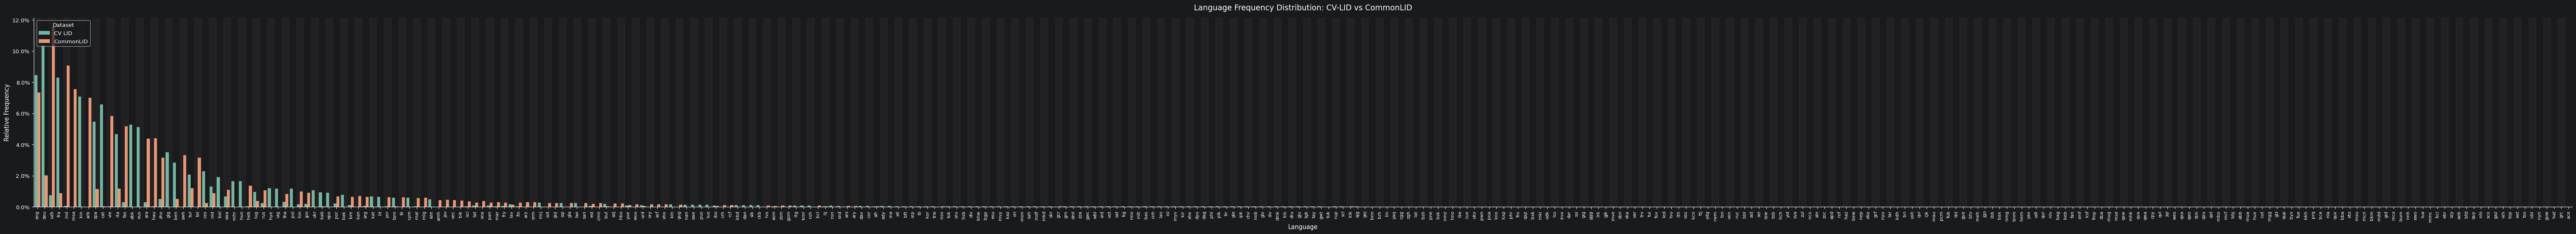

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, HTML
import io, base64


histogram_path = f"{cv_lid_untarred_path}/mcv_text_lid/language_histogram.csv"   # columns: lang, sentence

df_hist   = pd.read_csv(histogram_path)
df_hist.lang = df_hist.lang.astype(str).map(to_iso3)
df_hist = df_hist.groupby("lang").sum().reset_index()

# build per-language relative frequencies
counts_cvlid = df_hist.set_index("lang")["sentence"]
counts_commonlid = commonlid_df["lang"].value_counts()

all_languages = counts_cvlid.index.union(counts_commonlid.index)
counts_cvlid = counts_cvlid.reindex(all_languages, fill_value=0)
counts_commonlid = counts_commonlid.reindex(all_languages, fill_value=0)

freq_cvlid = (counts_cvlid / counts_cvlid.sum()).rename("CV LID")
freq_commonlid = (counts_commonlid / counts_commonlid.sum()).rename("CommonLID")

order = (freq_cvlid + freq_commonlid).sort_values(ascending=False).index

plot_df = (
    pd.DataFrame({"CV LID": freq_cvlid, "CommonLID": freq_commonlid}, index=all_languages)
    .loc[order]
    .reset_index()
    .rename(columns={"index": "lang"})
    .melt(id_vars="lang", var_name="Dataset", value_name="Frequency")
)


BAR_WIDTH_PX  = 18
n_langs       = len(order)
fig_width_in  = max(20, n_langs * BAR_WIDTH_PX / 96)
fig_height_in = 6
fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in))

sns.barplot(
    data=plot_df,
    x="lang",
    y="Frequency",
    hue="Dataset",
    palette="Set2",
    ax=ax,
)

# alternating background bands per language
for i in range(n_langs):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5, color="gray", alpha=0.08, zorder=0)

ax.set_title("Language Frequency Distribution: CV-LID vs CommonLID", fontsize=14, pad=14)
ax.set_xlabel("Language", fontsize=11)
ax.set_ylabel("Relative Frequency", fontsize=11)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.legend(title="Dataset", framealpha=0.7, loc="upper left")
ax.set_xlim(-0.5, n_langs - 0.5)
sns.despine()
plt.tight_layout()

# embed in a scrollable html cell
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=96, bbox_inches="tight")
plt.close(fig)
buf.seek(0)
b64 = base64.b64encode(buf.read()).decode()

display(HTML(f"""
<div style="overflow-x: auto; width: 100%; border: 1px solid #ddd; border-radius: 4px; padding: 4px;">
  <img src="data:image/png;base64,{b64}"
       style="height: 500px; width: auto; max-width: none; display: block;">
</div>
"""))

### Evaluate CV LID model on CommonLID
Now that we've seen that the language distribution is in fact quite different between the two datasets, let's see what this means for evaluating our CV LID model on CommonLID.

- Note that there is not a perfect overlap of label sets. we can look at performance on all common LID languages, and on only those languages that appear in both datasets.

In [18]:
X_dev = vectorizer.transform(commonlid_df["sentence"])
y_true_commonlid = np.array(commonlid_df["lang"])
y_pred_commonlid = clf.predict(X_dev)

In [23]:
# Build and print the full report

langs_in_commonlid = commonlid_df["lang"].unique()
langs_in_commonlid_and_cv_lid = list(set(langs_in_commonlid).intersection(df_hist.lang.unique()))

report_labels = langs_in_commonlid  # langs_in_commonlid_and_cv_lid
commonlid_report = classification_report(y_true_commonlid, y_pred_commonlid, output_dict=True, zero_division=0, labels=report_labels)
print(classification_report(y_true_commonlid, y_pred_commonlid, digits=3, zero_division=0, labels=report_labels))

              precision    recall  f1-score   support

         guj      0.000     0.000     0.000       948

   micro avg      0.000     0.000     0.000       948
   macro avg      0.000     0.000     0.000       948
weighted avg      0.000     0.000     0.000       948



## Diagnostic tools: some error analysis

An aggregate F1 score (or Precision or Recall) can hide a lot of important performance variation. Language ID models typically perform **very well on high-resource languages** (English, French, German) and **much worse on low-resource ones** (minority languages with little training data, or languages that are closely related to one another or to higher-resource languages).

The two functions below give us a way to:

1. **Rank all languages by F1** so we can quickly find where the model struggles.
2. **Drill into a specific language** to see which other languages it gets confused with.

Understanding confusions is often more actionable than the aggregate F1. e.g.:

- If Xish is consistently confused with Yish, that tells us the model needs more contrastive examples of those two languages, or that the n-gram range should be widened to capture longer distinguishing patterns.
- If a minority language is confused with many different languages randomly, it likely just lacks sufficient training data.

In [70]:
report = cv_lid_report
ALL_LANGUAGES = [lang for lang in list(report.keys()) if lang not in ('accuracy', 'macro avg', 'weighted avg')]

def show_worst_languages(n=20, min_support=50):
    """
    Print the n languages with the lowest F1 score.

    Parameters
    ----------
    n : int
        How many languages to display.
    min_support : int
        Exclude languages with fewer than this many test samples.
        Languages with very few samples will naturally score near
        zero due to small-sample noise, which can obscure genuinely
        problematic languages that have adequate test coverage.
    """
    scores = {
        lang: report[lang]
        for lang in ALL_LANGUAGES
        if lang in report and report[lang]["support"] >= min_support
    }
    ranked = sorted(scores.items(), key=lambda x: x[1]["f1-score"])[:n]

    print(f"Bottom {n} languages by F1 (min support = {min_support})\n")
    print(f"{'Rank':<6} {'Lang':<14} {'F1':>6}  {'Precision':>10}  {'Recall':>8}  {'Support':>9}")
    print("-" * 60)
    for i, (lang, r) in enumerate(ranked, 1):
        print(
            f"{i:<6} {lang:<14} {r['f1-score']:>6.3f}  "
            f"{r['precision']:>10.3f}  {r['recall']:>8.3f}  "
            f"{int(r['support']):>9}"
        )

In [71]:
y_true = y_true_cvlid # y_true_commonlid
y_pred = y_pred_cvlid # y_pred_commonlid
def show_confusions(lang, top_n=10):
    """
    For a given ground-truth language, show what the model predicted.

    This is a targeted confusion matrix -- instead of showing the full
    N x N matrix (which would be enormous with 200+ languages), we focus
    on a single row: all test samples where the true label is `lang`.

    Parameters
    ----------
    lang : str
        BCP-47 language code to investigate (e.g. 'ht', 'fr', 'zh-CN').
    top_n : int
        How many predicted labels to show (sorted by frequency).
    """
    mask = y_true == lang
    if mask.sum() == 0:
        print(f"No test samples found for '{lang}'.")
        return

    preds = y_pred[mask]
    total = len(preds)
    correct = (preds == lang).sum()

    print(f"Ground truth: '{lang}'  ({total} samples, {correct / total:.1%} correct)\n")
    print(f"  {'Predicted as':<20} {'Count':>7}  {'Share':>7}")
    print("  " + "-" * 38)

    counts = pd.Series(preds).value_counts()
    for pred_lang, count in counts.head(top_n).items():
        marker = "correct ->" if pred_lang == lang else "          "
        print(f"{marker} {pred_lang:<20} {count:>7}  {count / total:>7.1%}")

### Find the worst-performing languages

Run the cell below to see the 20 languages where the model struggles most. The `min_support=50` filter excludes any language with fewer than 50 test samples, so we are looking at **meaningful failures** rather than statistical noise from tiny test sets.

In [73]:
show_worst_languages(n=20, min_support=50)

Bottom 20 languages by F1 (min support = 50)

Rank   Lang               F1   Precision    Recall    Support
------------------------------------------------------------
1      yue             0.361       0.726     0.240        254
2      zho             0.653       0.915     0.507       1476
3      arg             0.667       0.519     0.930        172
4      nob             0.740       0.761     0.720         75
5      dmk             0.835       0.950     0.745         51
6      oci             0.836       0.775     0.908         87
7      jpn             0.839       0.993     0.726        551
8      por             0.844       0.867     0.823        665
9      slv             0.855       0.774     0.956         68
10     slk             0.878       0.945     0.821        312
11     ina             0.883       0.856     0.911        157
12     hau             0.887       0.816     0.973         73
13     ady             0.894       0.864     0.927        123
14     gju             0.

### 7b. Drill into a specific language's confusions

Pick any language from the list above (or any other language code) and call `show_confusions`. The output shows every label the model assigned when the ground truth was that language, sorted by frequency.

**How to interpret this:**

- A single dominant confusion (e.g. 60% of `ht` predicted as `fr`) suggests the two languages are too similar at the n-gram level -- they may need longer n-grams or more training data to pull apart.
- Many small confusions spread across unrelated languages suggests the model is essentially guessing -- likely a data scarcity problem for this language.
- High recall but low precision (lots of correct predictions here, but this language is also over-predicted for others) may indicate that this language's n-gram profile is very common or generic.

In [76]:
# Pass any language code you want to investigate
show_confusions('yue', top_n=10)

Ground truth: 'yue'  (254 samples, 24.0% correct)

  Predicted as           Count    Share
  --------------------------------------
           hat                      137    53.9%
correct -> yue                       61    24.0%
           zho                       56    22.0%


### Batch diagnosis -- top confusions for the worst performers

This cell automatically finds the 5 worst languages (by F1, with min support) and prints the confusion breakdown for each.

In [75]:
MIN_SUPPORT = 50
N_WORST = 5

scores = {
    lang: report[lang]["f1-score"]
    for lang in ALL_LANGUAGES
    if lang in report and report[lang]["support"] >= MIN_SUPPORT
}
worst_langs = sorted(scores, key=scores.get)[:N_WORST]

for lang in worst_langs:
    print("=" * 50)
    show_confusions(lang, top_n=5)
    print()

Ground truth: 'yue'  (254 samples, 24.0% correct)

  Predicted as           Count    Share
  --------------------------------------
           hat                      137    53.9%
correct -> yue                       61    24.0%
           zho                       56    22.0%

Ground truth: 'zho'  (1476 samples, 50.7% correct)

  Predicted as           Count    Share
  --------------------------------------
correct -> zho                      749    50.7%
           hat                      689    46.7%
           yue                       23     1.6%
           tel                        5     0.3%
           jpn                        3     0.2%

Ground truth: 'arg'  (172 samples, 93.0% correct)

  Predicted as           Count    Share
  --------------------------------------
correct -> arg                      160    93.0%
           spa                        6     3.5%
           glg                        4     2.3%
           slv                        1     0.6%
           ca